# Imports

In [1]:
import glob
import math
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
import os
from sklearn.preprocessing import MinMaxScaler
from sklearn.utils.class_weight import compute_class_weight
from sklearn.model_selection import train_test_split
from tensorflow.keras.models import Sequential
from tensorflow.keras.layers import Conv2D, MaxPooling2D, Flatten, Dense, Dropout
from tensorflow.keras.callbacks import EarlyStopping, ModelCheckpoint
from sklearn.metrics import classification_report, confusion_matrix, roc_curve, auc
from itertools import cycle

sns.set_theme(style="whitegrid")
plt.rcParams['figure.figsize'] = (12, 8) 

pd.set_option('display.max_columns', None)

# Combining and loading datasets

In [2]:
def load_and_combine_data(directory_path):
    print(f"Scanning directory: {directory_path} for CSV files.")
    
    csv_files = glob.glob(os.path.join(directory_path, "*.csv"))
    
    if not csv_files:
        print("No CSV files found! Please check the directory path.")
        return None
    
    print(f"Found {len(csv_files)} files. Combining them.")
    
    df_list = []
    for file in csv_files:
        print(f"Loading: {os.path.basename(file)}")
        temp_df = pd.read_csv(file, low_memory=False) 
        
        temp_df.columns = temp_df.columns.str.strip()
        df_list.append(temp_df)
        
    combined_df = pd.concat(df_list, ignore_index=True)
    
    print(f"\nAll datasets combined. Final shape: {combined_df.shape}")
    return combined_df

dataset_dir = './datasets'
df = load_and_combine_data(dataset_dir)

df.head()

Scanning directory: ./datasets for CSV files.
Found 8 files. Combining them.
Loading: Friday-WorkingHours-Afternoon-DDos.pcap_ISCX.csv
Loading: Friday-WorkingHours-Afternoon-PortScan.pcap_ISCX.csv
Loading: Friday-WorkingHours-Morning.pcap_ISCX.csv
Loading: Monday-WorkingHours.pcap_ISCX.csv
Loading: Thursday-WorkingHours-Afternoon-Infilteration.pcap_ISCX.csv
Loading: Thursday-WorkingHours-Morning-WebAttacks.pcap_ISCX.csv
Loading: Tuesday-WorkingHours.pcap_ISCX.csv
Loading: Wednesday-workingHours.pcap_ISCX.csv

All datasets combined. Final shape: (2830743, 79)


,Destination Port,Flow Duration,Total Fwd Packets,Total Backward Packets,Total Length of Fwd Packets,Total Length of Bwd Packets,Fwd Packet Length Max,Fwd Packet Length Min,Fwd Packet Length Mean,Fwd Packet Length Std,Bwd Packet Length Max,Bwd Packet Length Min,Bwd Packet Length Mean,Bwd Packet Length Std,Flow Bytes/s,Flow Packets/s,Flow IAT Mean,Flow IAT Std,Flow IAT Max,Flow IAT Min,Fwd IAT Total,Fwd IAT Mean,Fwd IAT Std,Fwd IAT Max,Fwd IAT Min,Bwd IAT Total,Bwd IAT Mean,Bwd IAT Std,Bwd IAT Max,Bwd IAT Min,Fwd PSH Flags,Bwd PSH Flags,Fwd URG Flags,Bwd URG Flags,Fwd Header Length,Bwd Header Length,Fwd Packets/s,Bwd Packets/s,Min Packet Length,Max Packet Length,Packet Length Mean,Packet Length Std,Packet Length Variance,FIN Flag Count,SYN Flag Count,RST Flag Count,PSH Flag Count,ACK Flag Count,URG Flag Count,CWE Flag Count,ECE Flag Count,Down/Up Ratio,Average Packet Size,Avg Fwd Segment Size,Avg Bwd Segment Size,Fwd Header Length.1,Fwd Avg Bytes/Bulk,Fwd Avg Packets/Bulk,Fwd Avg Bulk Rate,Bwd Avg Bytes/Bulk,Bwd Avg Packets/Bulk,Bwd Avg Bulk Rate,Subflow Fwd Packets,Subflow Fwd Bytes,Subflow Bwd Packets,Subflow Bwd Bytes,Init_Win_bytes_forward,Init_Win_bytes_backward,act_data_pkt_fwd,min_seg_size_forward,Active Mean,Active Std,Active Max,Active Min,Idle Mean,Idle Std,Idle Max,Idle Min,Label
0,54865,3,2,0,12,0,6,6,6.0,0.0,0,0,0.0,0.0,4.000000e+06,666666.66670,3.0,0.0,3,3,3,3.0,0.0,3,3,0,0.0,0.0,0,0,0,0,0,0,40,0,666666.666700,0.000000,6,6,6.0,0.0,0.0,0,0,0,0,1,0,0,0,0,9.0,6.0,0.0,40,0,0,0,0,0,0,2,12,0,0,33,-1,1,20,0.0,0.0,0,0,0.0,0.0,0,0,BENIGN
1,55054,109,1,1,6,6,6,6,6.0,0.0,6,6,6.0,0.0,1.100917e+05,18348.62385,109.0,0.0,109,109,0,0.0,0.0,0,0,0,0.0,0.0,0,0,0,0,0,0,20,20,9174.311927,9174.311927,6,6,6.0,0.0,0.0,0,0,0,0,1,1,0,0,1,9.0,6.0,6.0,20,0,0,0,0,0,0,1,6,1,6,29,256,0,20,0.0,0.0,0,0,0.0,0.0,0,0,BENIGN
2,55055,52,1,1,6,6,6,6,6.0,0.0,6,6,6.0,0.0,2.307692e+05,38461.53846,52.0,0.0,52,52,0,0.0,0.0,0,0,0,0.0,0.0,0,0,0,0,0,0,20,20,19230.769230,19230.769230,6,6,6.0,0.0,0.0,0,0,0,0,1,1,0,0,1,9.0,6.0,6.0,20,0,0,0,0,0,0,1,6,1,6,29,256,0,20,0.0,0.0,0,0,0.0,0.0,0,0,BENIGN
3,46236,34,1,1,6,6,6,6,6.0,0.0,6,6,6.0,0.0,3.529412e+05,58823.52941,34.0,0.0,34,34,0,0.0,0.0,0,0,0,0.0,0.0,0,0,0,0,0,0,20,20,29411.764710,29411.764710,6,6,6.0,0.0,0.0,0,0,0,0,1,1,0,0,1,9.0,6.0,6.0,20,0,0,0,0,0,0,1,6,1,6,31,329,0,20,0.0,0.0,0,0,0.0,0.0,0,0,BENIGN
4,54863,3,2,0,12,0,6,6,6.0,0.0,0,0,0.0,0.0,4.000000e+06,666666.66670,3.0,0.0,3,3,3,3.0,0.0,3,3,0,0.0,0.0,0,0,0,0,0,0,40,0,666666.666700,0.000000,6,6,6.0,0.0,0.0,0,0,0,0,1,0,0,0,0,9.0,6.0,0.0,40,0,0,0,0,0,0,2,12,0,0,32,-1,1,20,0.0,0.0,0,0,0.0,0.0,0,0,BENIGN


# Exploratory Data Analysis

In [3]:
def dataset_overview(df):
    print("Dataset Info")
    df.info()
    
    print("\nSummary Statistics (Numerical Features)")
    display(df.describe())

dataset_overview(df)

Dataset Info
<class 'pandas.core.frame.DataFrame'>
RangeIndex: 2830743 entries, 0 to 2830742
Data columns (total 79 columns):
 #   Column                       Dtype  
---  ------                       -----  
 0   Destination Port             int64  
 1   Flow Duration                int64  
 2   Total Fwd Packets            int64  
 3   Total Backward Packets       int64  
 4   Total Length of Fwd Packets  int64  
 5   Total Length of Bwd Packets  int64  
 6   Fwd Packet Length Max        int64  
 7   Fwd Packet Length Min        int64  
 8   Fwd Packet Length Mean       float64
 9   Fwd Packet Length Std        float64
 10  Bwd Packet Length Max        int64  
 11  Bwd Packet Length Min        int64  
 12  Bwd Packet Length Mean       float64
 13  Bwd Packet Length Std        float64
 14  Flow Bytes/s                 float64
 15  Flow Packets/s               float64
 16  Flow IAT Mean                float64
 17  Flow IAT Std                 float64
 18  Flow IAT Max                 

C:\Users\ankus\AppData\Roaming\Python\Python313\site-packages\pandas\core\nanops.py:1016: RuntimeWarning: invalid value encountered in subtract
  sqr = _ensure_numeric((avg - values) ** 2)
C:\Users\ankus\AppData\Roaming\Python\Python313\site-packages\pandas\core\nanops.py:1016: RuntimeWarning: invalid value encountered in subtract
  sqr = _ensure_numeric((avg - values) ** 2)


,Destination Port,Flow Duration,Total Fwd Packets,Total Backward Packets,Total Length of Fwd Packets,Total Length of Bwd Packets,Fwd Packet Length Max,Fwd Packet Length Min,Fwd Packet Length Mean,Fwd Packet Length Std,Bwd Packet Length Max,Bwd Packet Length Min,Bwd Packet Length Mean,Bwd Packet Length Std,Flow Bytes/s,Flow Packets/s,Flow IAT Mean,Flow IAT Std,Flow IAT Max,Flow IAT Min,Fwd IAT Total,Fwd IAT Mean,Fwd IAT Std,Fwd IAT Max,Fwd IAT Min,Bwd IAT Total,Bwd IAT Mean,Bwd IAT Std,Bwd IAT Max,Bwd IAT Min,Fwd PSH Flags,Bwd PSH Flags,Fwd URG Flags,Bwd URG Flags,Fwd Header Length,Bwd Header Length,Fwd Packets/s,Bwd Packets/s,Min Packet Length,Max Packet Length,Packet Length Mean,Packet Length Std,Packet Length Variance,FIN Flag Count,SYN Flag Count,RST Flag Count,PSH Flag Count,ACK Flag Count,URG Flag Count,CWE Flag Count,ECE Flag Count,Down/Up Ratio,Average Packet Size,Avg Fwd Segment Size,Avg Bwd Segment Size,Fwd Header Length.1,Fwd Avg Bytes/Bulk,Fwd Avg Packets/Bulk,Fwd Avg Bulk Rate,Bwd Avg Bytes/Bulk,Bwd Avg Packets/Bulk,Bwd Avg Bulk Rate,Subflow Fwd Packets,Subflow Fwd Bytes,Subflow Bwd Packets,Subflow Bwd Bytes,Init_Win_bytes_forward,Init_Win_bytes_backward,act_data_pkt_fwd,min_seg_size_forward,Active Mean,Active Std,Active Max,Active Min,Idle Mean,Idle Std,Idle Max,Idle Min
count,2.830743e+06,2.830743e+06,2.830743e+06,2.830743e+06,2.830743e+06,2.830743e+06,2.830743e+06,2.830743e+06,2.830743e+06,2.830743e+06,2.830743e+06,2.830743e+06,2.830743e+06,2.830743e+06,2.829385e+06,2.830743e+06,2.830743e+06,2.830743e+06,2.830743e+06,2.830743e+06,2.830743e+06,2.830743e+06,2.830743e+06,2.830743e+06,2.830743e+06,2.830743e+06,2.830743e+06,2.830743e+06,2.830743e+06,2.830743e+06,2.830743e+06,2830743.0,2.830743e+06,2830743.0,2.830743e+06,2.830743e+06,2.830743e+06,2.830743e+06,2.830743e+06,2.830743e+06,2.830743e+06,2.830743e+06,2.830743e+06,2.830743e+06,2.830743e+06,2.830743e+06,2.830743e+06,2.830743e+06,2.830743e+06,2.830743e+06,2.830743e+06,2.830743e+06,2.830743e+06,2.830743e+06,2.830743e+06,2.830743e+06,2830743.0,2830743.0,2830743.0,2830743.0,2830743.0,2830743.0,2.830743e+06,2.830743e+06,2.830743e+06,2.830743e+06,2.830743e+06,2.830743e+06,2.830743e+06,2.830743e+06,2.830743e+06,2.830743e+06,2.830743e+06,2.830743e+06,2.830743e+06,2.830743e+06,2.830743e+06,2.830743e+06
mean,8.071483e+03,1.478566e+07,9.361160e+00,1.039377e+01,5.493024e+02,1.616264e+04,2.075999e+02,1.871366e+01,5.820194e+01,6.891013e+01,8.708495e+02,4.104958e+01,3.059493e+02,3.353257e+02,inf,inf,1.298449e+06,2.919271e+06,9.182475e+06,1.623796e+05,1.448296e+07,2.610193e+06,3.266957e+06,9.042939e+06,1.021893e+06,9.893830e+06,1.805784e+06,1.485973e+06,4.684692e+06,9.672614e+05,4.644646e-02,0.0,1.112782e-04,0.0,-2.599739e+04,-2.273275e+03,6.386535e+04,6.995192e+03,1.643450e+01,9.504024e+02,1.719444e+02,2.949756e+02,4.861548e+05,3.537976e-02,4.644646e-02,2.423392e-04,2.980705e-01,3.158443e-01,9.482316e-02,1.112782e-04,2.433990e-04,6.835004e-01,1.919837e+02,5.820194e+01,3.059493e+02,-2.599739e+04,0.0,0.0,0.0,0.0,0.0,0.0,9.361160e+00,5.492919e+02,1.039377e+01,1.616230e+04,6.989837e+03,1.989433e+03,5.418218e+00,-2.741688e+03,8.155132e+04,4.113412e+04,1.531825e+05,5.829582e+04,8.316037e+06,5.038439e+05,8.695752e+06,7.920031e+06
std,1.828363e+04,3.365374e+07,7.496728e+02,9.973883e+02,9.993589e+03,2.263088e+06,7.171848e+02,6.033935e+01,1.860912e+02,2.811871e+02,1.946367e+03,6.886260e+01,6.052568e+02,8.396932e+02,NaN,NaN,4.507944e+06,8.045870e+06,2.445954e+07,2.950282e+06,3.357581e+07,9.525722e+06,9.639055e+06,2.452916e+07,8.591436e+06,2.873661e+07,8.887197e+06,6.278469e+06,1.716095e+07,8.308983e+06,2.104500e-01,0.0,1.054826e-02,0.0,2.105286e+07,1.452209e+06,2.475371e+05,3.815170e+04,2.523772e+01,2.028229e+03,3.054915e+02,6.318001e+02,1.647490e+06,1.847378e-01,2.104500e-01,1.556536e-02,4.574107e-01,4.648513e-01,2.929706e-01,1.054826e-02,1.559935e-02,6.804920e-01,3.318603e+02,1.860912e+02,6.052568e+02,2.105286e+07,0.0,0.0,0.0,0.0,0.0,0.0,7.496728e+02,9.980070e+03,9.973883e+02,2.26305

In [4]:
def check_anomalies(df):
    missing_values = df.isnull().sum().sum()
    print(f"Total missing (NaN) values in dataset: {missing_values}")
    
    if missing_values > 0:
        print(df.isnull().sum()[df.isnull().sum() > 0])
        
    numeric_cols = df.select_dtypes(include=[np.number]).columns
    inf_values = np.isinf(df[numeric_cols]).sum().sum()
    print(f"\nTotal infinite (Inf) values in dataset: {inf_values}")
    
    if inf_values > 0:
        inf_counts = np.isinf(df[numeric_cols]).sum()
        print(inf_counts[inf_counts > 0])

check_anomalies(df)

Total missing (NaN) values in dataset: 1358
Flow Bytes/s    1358
dtype: int64

Total infinite (Inf) values in dataset: 4376
Flow Bytes/s      1509
Flow Packets/s    2867
dtype: int64


Master Class Distribution
Label
BENIGN                        2273097
DoS Hulk                       231073
PortScan                       158930
DDoS                           128027
DoS GoldenEye                   10293
FTP-Patator                      7938
SSH-Patator                      5897
DoS slowloris                    5796
DoS Slowhttptest                 5499
Bot                              1966
Web Attack � Brute Force         1507
Web Attack � XSS                  652
Infiltration                       36
Web Attack � Sql Injection         21
Heartbleed                         11
Name: count, dtype: int64

Class Percentages:
 Label
BENIGN                        80.300366
DoS Hulk                       8.162981
PortScan                       5.614427
DDoS                           4.522735
DoS GoldenEye                  0.363615
FTP-Patator                    0.280421
SSH-Patator                    0.208320
DoS slowloris                  0.204752
DoS Slowhttptest         

C:\Users\ankus\AppData\Local\Temp\ipykernel_33912\3040720009.py:8: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `y` variable to `hue` and set `legend=False` for the same effect.

  sns.countplot(data=df, y=target_col, order=class_counts.index, palette='viridis')
C:\Users\ankus\AppData\Local\Temp\ipykernel_33912\3040720009.py:13: UserWarning: Glyph 65533 (\N{REPLACEMENT CHARACTER}) missing from font(s) Arial.
  plt.tight_layout()
C:\Users\ankus\AppData\Roaming\Python\Python313\site-packages\IPython\core\pylabtools.py:170: UserWarning: Glyph 65533 (\N{REPLACEMENT CHARACTER}) missing from font(s) Arial.
  fig.canvas.print_figure(bytes_io, **kw)


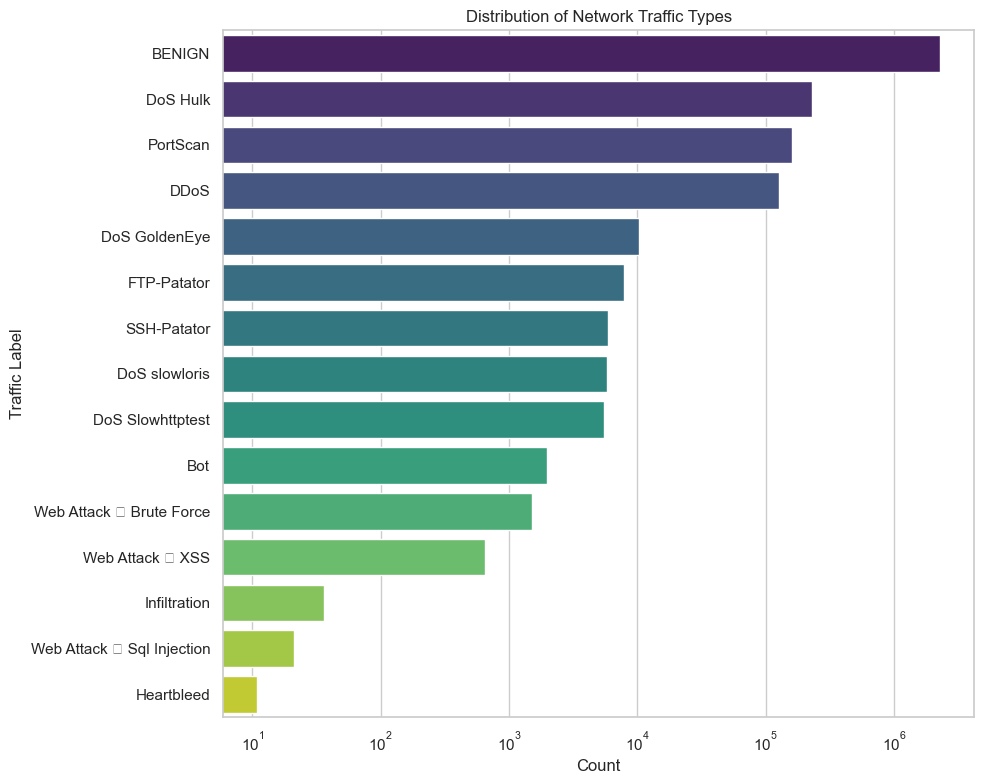

In [5]:
def plot_target_distribution(df, target_col='Label'):
    class_counts = df[target_col].value_counts()
    print("Master Class Distribution")
    print(class_counts)
    print("\nClass Percentages:\n", (class_counts / len(df)) * 100)
    
    plt.figure(figsize=(10, 8))
    sns.countplot(data=df, y=target_col, order=class_counts.index, palette='viridis')
    plt.title('Distribution of Network Traffic Types')
    plt.xlabel('Count')
    plt.ylabel('Traffic Label')
    plt.xscale('log') 
    plt.tight_layout()
    plt.show()

plot_target_distribution(df)

# Data Cleaning

In [6]:
def clean_dataset(df):
    print(f"Shape before cleaning: {df.shape}")
    
    df['Label'] = df['Label'].astype(str).str.replace(r'[^\x00-\x7F]+', ' ', regex=True)
    df['Label'] = df['Label'].str.replace('  ', ' ', regex=False).str.strip()
    
    df.replace([np.inf, -np.inf], np.nan, inplace=True)
    
    df.dropna(inplace=True)
    
    df.drop_duplicates(inplace=True)
    
    print(f"Shape after cleaning: {df.shape}")
    return df

df_clean = clean_dataset(df)

Shape before cleaning: (2830743, 79)
Shape after cleaning: (2520798, 79)


# Class Consolidation and Filtering

In [7]:
def consolidate_and_filter_classes(df, min_samples=1000):
    df['Label'] = df['Label'].apply(lambda x: 'Web Attack' if 'Web Attack' in x else x)
    
    class_counts = df['Label'].value_counts()
    valid_classes = class_counts[class_counts >= min_samples].index
    
    df_filtered = df[df['Label'].isin(valid_classes)]
    
    print("Classes after Consolidation and Filtering")
    print(df_filtered['Label'].value_counts())
    
    return df_filtered

df_filtered = consolidate_and_filter_classes(df_clean)

Classes after Consolidation and Filtering
Label
BENIGN              2095057
DoS Hulk             172846
DDoS                 128014
PortScan              90694
DoS GoldenEye         10286
FTP-Patator            5931
DoS slowloris          5385
DoS Slowhttptest       5228
SSH-Patator            3219
Web Attack             2143
Bot                    1948
Name: count, dtype: int64


# Undersampling BENIGN Network Traffic (Balancing the dataset)

In [8]:
def balance_dataset(df, target_col='Label', majority_class='BENIGN', cap_size=500000):
    df_majority = df[df[target_col] == majority_class]
    df_attacks = df[df[target_col] != majority_class]
    
    print(f"Original Majority count: {len(df_majority)}, Original Attacks count: {len(df_attacks)}")
    
    df_majority_downsampled = df_majority.sample(n=cap_size, random_state=42)
    
    df_balanced = pd.concat([df_majority_downsampled, df_attacks])
    
    df_balanced = df_balanced.sample(frac=1, random_state=42).reset_index(drop=True)
    
    print("\nFinal Balanced Class Distribution")
    print(df_balanced[target_col].value_counts())
    
    return df_balanced

df_balanced = balance_dataset(df_filtered)

Original Majority count: 2095057, Original Attacks count: 425694

Final Balanced Class Distribution
Label
BENIGN              500000
DoS Hulk            172846
DDoS                128014
PortScan             90694
DoS GoldenEye        10286
FTP-Patator           5931
DoS slowloris         5385
DoS Slowhttptest      5228
SSH-Patator           3219
Web Attack            2143
Bot                   1948
Name: count, dtype: int64


# Feature Separation and Zero-Variance Removal

In [9]:
X_raw = df_balanced.drop(columns=['Label'])
y_raw = df_balanced['Label']

zero_var_cols = X_raw.columns[X_raw.std() == 0]
if len(zero_var_cols) > 0:
    print(f"Dropping {len(zero_var_cols)} zero-variance columns: {list(zero_var_cols)}")
    X_reduced = X_raw.drop(columns=zero_var_cols)
else:
    print("No zero-variance columns found.")
    X_reduced = X_raw

num_features = X_reduced.shape[1]
print(f"Final number of valid numerical features: {num_features}")

Dropping 8 zero-variance columns: ['Bwd PSH Flags', 'Bwd URG Flags', 'Fwd Avg Bytes/Bulk', 'Fwd Avg Packets/Bulk', 'Fwd Avg Bulk Rate', 'Bwd Avg Bytes/Bulk', 'Bwd Avg Packets/Bulk', 'Bwd Avg Bulk Rate']
Final number of valid numerical features: 70


# Dynamic 2D Transformation and Scaling

In [10]:
def transform_to_images(X_raw):
    print("Scaling features between 0 and 1.")
    scaler = MinMaxScaler()
    X_scaled = scaler.fit_transform(X_raw)
     
    current_features = X_scaled.shape[1]
    grid_size = math.ceil(math.sqrt(current_features))
    target_features = grid_size * grid_size
    padding_needed = target_features - current_features
    
    print(f"Current features: {current_features}")
    print(f"Target grid: {grid_size}x{grid_size} ({target_features} elements)")
    print(f"Padding each record with {padding_needed} zeros.")
    
    X_padded = np.pad(X_scaled, ((0, 0), (0, padding_needed)), mode='constant', constant_values=0)
    
    X_img = X_padded.reshape(-1, grid_size, grid_size, 1)
    
    print(f"Mathematical transformation complete. New shape: {X_img.shape}")
    return X_img, grid_size

X_img, grid_size = transform_to_images(X_reduced)

Scaling features between 0 and 1.
Current features: 70
Target grid: 9x9 (81 elements)
Padding each record with 11 zeros.
Mathematical transformation complete. New shape: (925694, 9, 9, 1)


# Multi-Class Label Encoding & Train/Test Split

In [11]:
y_encoded = pd.get_dummies(y_raw).values
label_names = pd.get_dummies(y_raw).columns.tolist()

print(f"Discovered Classes ({len(label_names)} total): {label_names}")

X_train, X_test, y_train, y_test = train_test_split(
    X_img, y_encoded, test_size=0.2, random_state=42, stratify=y_encoded
)

print(f"\nTraining set shape: X={X_train.shape}, y={y_train.shape}")
print(f"Testing set shape: X={X_test.shape}, y={y_test.shape}")

Discovered Classes (11 total): ['BENIGN', 'Bot', 'DDoS', 'DoS GoldenEye', 'DoS Hulk', 'DoS Slowhttptest', 'DoS slowloris', 'FTP-Patator', 'PortScan', 'SSH-Patator', 'Web Attack']

Training set shape: X=(740555, 9, 9, 1), y=(740555, 11)
Testing set shape: X=(185139, 9, 9, 1), y=(185139, 11)


# Visualizing the 9x9 Traffic Matrices

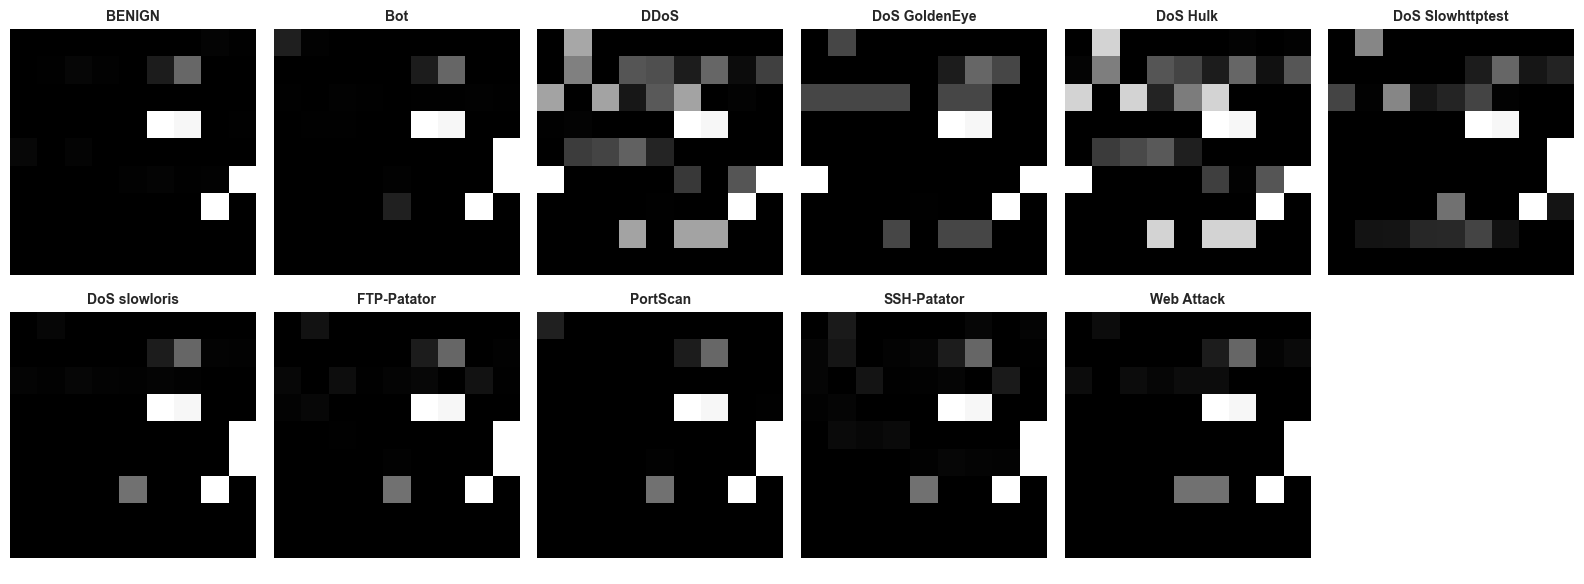

In [12]:
def visualize_multi_class_traffic(X_img, y_raw, label_names):
    fig, axes = plt.subplots(2, 6, figsize=(16, 6)) 
    axes = axes.flatten()
    
    for i, cls in enumerate(label_names):
        idx = y_raw[y_raw == cls].index[0]
        
        img = X_img[idx].reshape(9, 9)
        
        ax = axes[i]
        cax = ax.imshow(img, cmap='gray', vmin=0, vmax=1)
        ax.set_title(f"{cls}", fontsize=10, fontweight='bold')
        ax.axis('off')
        
    axes[-1].axis('off')
    
    plt.tight_layout()
    plt.show()

visualize_multi_class_traffic(X_img, y_raw, label_names)

# CNN Architecture

In [13]:
def build_cnn(input_shape, num_classes):
    print(f"Building CNN for input shape {input_shape} and {num_classes} classes...")
    model = Sequential()
    
    model.add(Conv2D(32, kernel_size=(3, 3), padding='same', activation='relu', input_shape=input_shape))
    model.add(Conv2D(64, kernel_size=(3, 3), padding='same', activation='relu'))
    
    model.add(MaxPooling2D(pool_size=(2, 2)))
    
    model.add(Flatten())
    
    model.add(Dense(128, activation='relu'))
    model.add(Dropout(0.5)) 
    model.add(Dense(num_classes, activation='softmax'))
    
    model.compile(optimizer='adam', 
                  loss='categorical_crossentropy', 
                  metrics=['accuracy'])
    
    return model

input_shape = (grid_size, grid_size, 1) 
num_classes = len(label_names)

model = build_cnn(input_shape, num_classes)
model.summary()

Building CNN for input shape (9, 9, 1) and 11 classes...


C:\Users\ankus\AppData\Roaming\Python\Python313\site-packages\keras\src\layers\convolutional\base_conv.py:113: UserWarning: Do not pass an `input_shape`/`input_dim` argument to a layer. When using Sequential models, prefer using an `Input(shape)` object as the first layer in the model instead.
  super().__init__(activity_regularizer=activity_regularizer, **kwargs)


Model: "sequential"

┏━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━┓
┃ Layer (type)                    ┃ Output Shape           ┃       Param # ┃
┡━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━┩
│ conv2d (Conv2D)                 │ (None, 9, 9, 32)       │           320 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ conv2d_1 (Conv2D)               │ (None, 9, 9, 64)       │        18,496 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ max_pooling2d (MaxPooling2D)    │ (None, 4, 4, 64)       │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ flatten (Flatten)               │ (None, 1024)           │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense (Dense)                   │ (None, 128)            │       131,200 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dropout (Dropout)               │ (None, 128)            │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_1 (Dense)                 │ (None, 11)             │         1,419 │
└─────────────────────────────────┴────────────────────────┴───────────────┘

 Total params: 151,435 (591.54 KB)

 Trainable params: 151,435 (591.54 KB)

 Non-trainable params: 0 (0.00 B)

# Calculating Class Weights

In [14]:
def calculate_class_weights(y_raw_labels):
    classes = np.unique(y_raw_labels)
    weights = compute_class_weight(class_weight='balanced', classes=classes, y=y_raw_labels)
    class_weights_dict = dict(zip(range(len(classes)), weights))
    
    for cls, weight in zip(classes, weights):
        print(f"Class '{cls}': Weight {weight:.4f}")
        
    return class_weights_dict

class_weights = calculate_class_weights(y_raw)

Class 'BENIGN': Weight 0.1683
Class 'Bot': Weight 43.2002
Class 'DDoS': Weight 0.6574
Class 'DoS GoldenEye': Weight 8.1814
Class 'DoS Hulk': Weight 0.4869
Class 'DoS Slowhttptest': Weight 16.0968
Class 'DoS slowloris': Weight 15.6275
Class 'FTP-Patator': Weight 14.1888
Class 'PortScan': Weight 0.9279
Class 'SSH-Patator': Weight 26.1429
Class 'Web Attack': Weight 39.2692


# Model Training

In [15]:
def train_model(model, X_train, y_train, X_test, y_test, class_weights_dict, batch_size=64, epochs=50):
    checkpoint_dir = './Checkpoints'
    os.makedirs(checkpoint_dir, exist_ok=True)
    
    early_stop = EarlyStopping(monitor='val_loss', patience=3, restore_best_weights=True)
    
    checkpoint_path = os.path.join(checkpoint_dir, 'cnn_model_epoch_{epoch:02d}_val_acc_{val_accuracy:.4f}.keras')
    checkpointing = ModelCheckpoint(
        filepath=checkpoint_path,
        monitor='val_loss',
        save_best_only=True,
        save_weights_only=False,
        verbose=1
    )
    
    print("\\nStarting model training...")
    history = model.fit(
        X_train, y_train,
        validation_data=(X_test, y_test),
        epochs=epochs,
        batch_size=batch_size,
        class_weight=class_weights_dict,
        callbacks=[early_stop, checkpointing],
        verbose=1
    )
    return history

history = train_model(model, X_train, y_train, X_test, y_test, class_weights)

\nStarting model training...
Epoch 1/50
11570/11572 ━━━━━━━━━━━━━━━━━━━━ 0s 11ms/step - accuracy: 0.7427 - loss: 0.6841
Epoch 1: val_loss improved from None to 0.22401, saving model to ./Checkpoints\cnn_model_epoch_01_val_acc_0.9133.keras

Epoch 1: finished saving model to ./Checkpoints\cnn_model_epoch_01_val_acc_0.9133.keras
11572/11572 ━━━━━━━━━━━━━━━━━━━━ 146s 12ms/step - accuracy: 0.8270 - loss: 0.3743 - val_accuracy: 0.9133 - val_loss: 0.2240
Epoch 2/50
11568/11572 ━━━━━━━━━━━━━━━━━━━━ 0s 10ms/step - accuracy: 0.8968 - loss: 0.1574
Epoch 2: val_loss improved from 0.22401 to 0.20373, saving model to ./Checkpoints\cnn_model_epoch_02_val_acc_0.9214.keras

Epoch 2: finished saving model to ./Checkpoints\cnn_model_epoch_02_val_acc_0.9214.keras
11572/11572 ━━━━━━━━━━━━━━━━━━━━ 130s 11ms/step - accuracy: 0.9003 - loss: 0.1512 - val_accuracy: 0.9214 - val_loss: 0.2037
Epoch 3/50
11572/11572 ━━━━━━━━━━━━━━━━━━━━ 0s 11ms/step - accuracy: 0.9116 - loss: 0.1320
Epoch 3: val_loss did not impro

# Visualizing Training History

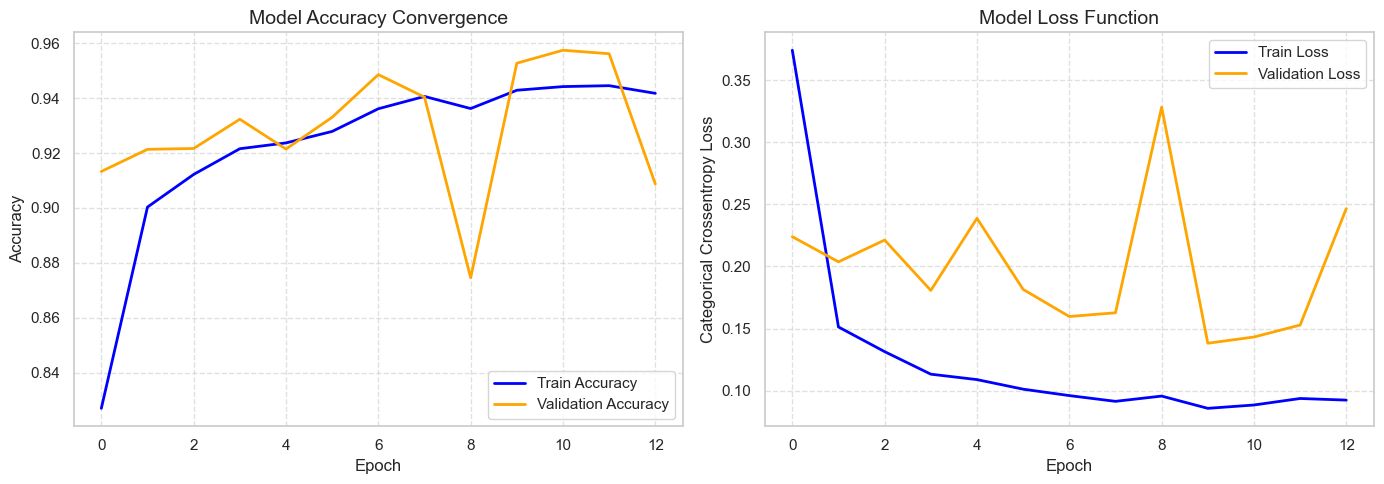

In [16]:
def plot_training_history(history):
    fig, axes = plt.subplots(1, 2, figsize=(14, 5))
    
    axes[0].plot(history.history['accuracy'], label='Train Accuracy', color='blue', linewidth=2)
    axes[0].plot(history.history['val_accuracy'], label='Validation Accuracy', color='orange', linewidth=2)
    axes[0].set_title('Model Accuracy Convergence', fontsize=14)
    axes[0].set_xlabel('Epoch', fontsize=12)
    axes[0].set_ylabel('Accuracy', fontsize=12)
    axes[0].legend(loc='lower right')
    axes[0].grid(True, linestyle='--', alpha=0.6)
    
    axes[1].plot(history.history['loss'], label='Train Loss', color='blue', linewidth=2)
    axes[1].plot(history.history['val_loss'], label='Validation Loss', color='orange', linewidth=2)
    axes[1].set_title('Model Loss Function', fontsize=14)
    axes[1].set_xlabel('Epoch', fontsize=12)
    axes[1].set_ylabel('Categorical Crossentropy Loss', fontsize=12)
    axes[1].legend(loc='upper right')
    axes[1].grid(True, linestyle='--', alpha=0.6)
    
    plt.tight_layout()
    plt.show()

plot_training_history(history)

# Evaluation

### Classification Report & Confusion Matrix

5786/5786 ━━━━━━━━━━━━━━━━━━━━ 17s 3ms/step
CLASSIFICATION REPORT
                  precision    recall  f1-score   support

          BENIGN       1.00      0.91      0.96    100000
             Bot       0.12      0.98      0.22       389
            DDoS       0.98      1.00      0.99     25603
   DoS GoldenEye       0.87      0.99      0.93      2057
        DoS Hulk       0.98      1.00      0.99     34569
DoS Slowhttptest       0.91      0.99      0.95      1046
   DoS slowloris       0.94      0.97      0.95      1077
     FTP-Patator       0.95      1.00      0.97      1186
        PortScan       0.91      1.00      0.95     18139
     SSH-Patator       0.39      0.99      0.56       644
      Web Attack       0.23      0.94      0.37       429

        accuracy                           0.95    185139
       macro avg       0.75      0.98      0.80    185139
    weighted avg       0.98      0.95      0.96    185139





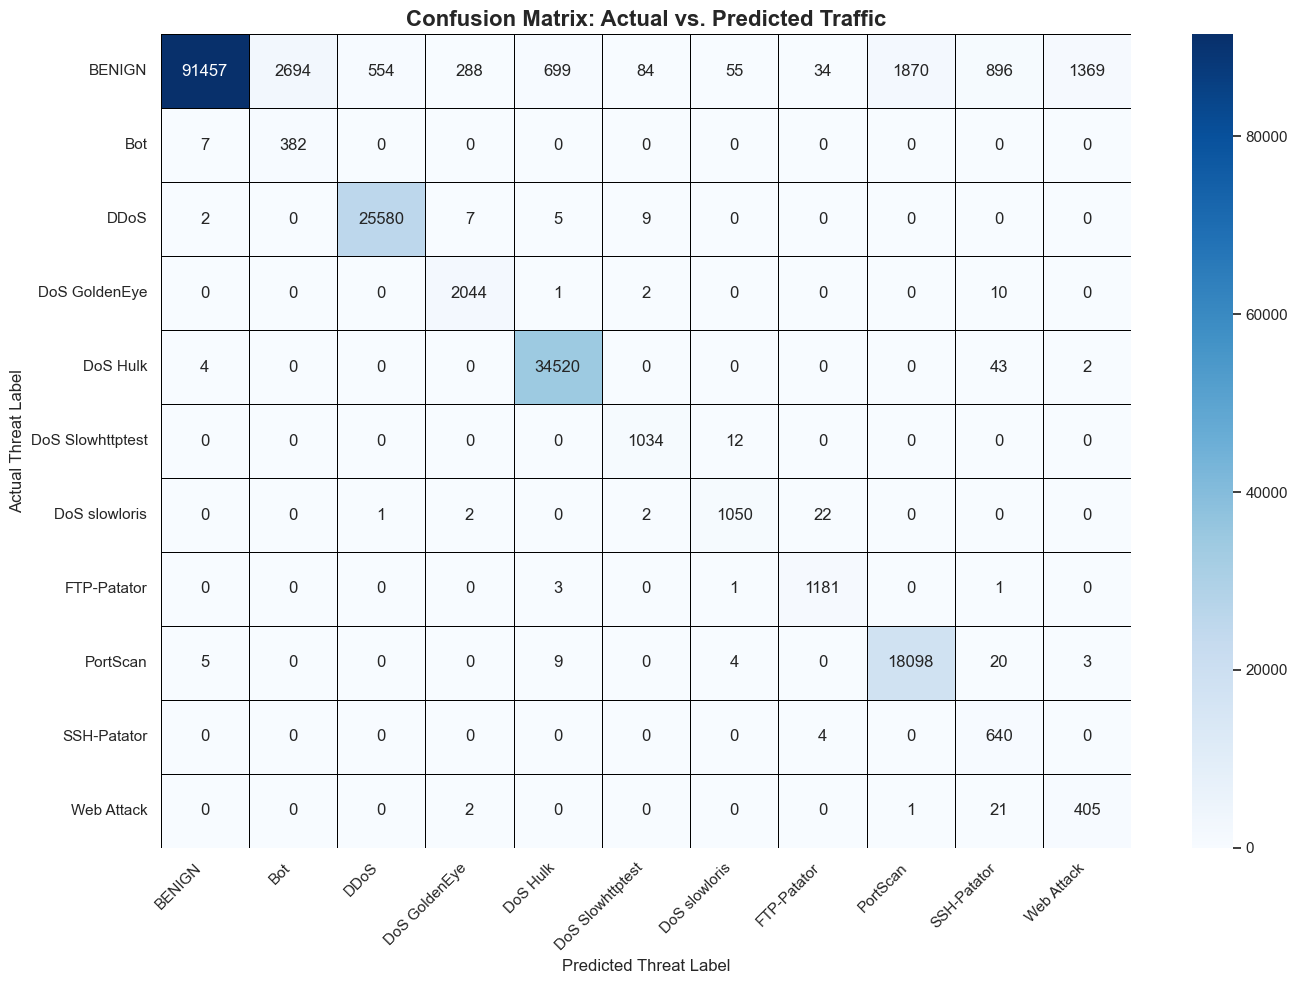

In [17]:
y_pred_prob = model.predict(X_test)
y_pred_classes = np.argmax(y_pred_prob, axis=1)
y_true_classes = np.argmax(y_test, axis=1)

def evaluate_classification(y_true, y_pred, labels):
    print("CLASSIFICATION REPORT")
    print(classification_report(y_true, y_pred, target_names=labels))
    print("\n")
    
    cm = confusion_matrix(y_true, y_pred)
    plt.figure(figsize=(14, 10))
    sns.heatmap(cm, annot=True, fmt='d', cmap='Blues', 
                xticklabels=labels, yticklabels=labels,
                linewidths=0.5, linecolor='black')
    
    plt.title('Confusion Matrix: Actual vs. Predicted Traffic', fontsize=16, fontweight='bold')
    plt.xlabel('Predicted Threat Label', fontsize=12)
    plt.ylabel('Actual Threat Label', fontsize=12)
    plt.xticks(rotation=45, ha='right')
    plt.tight_layout()
    plt.show()

evaluate_classification(y_true_classes, y_pred_classes, label_names)

### ROC Curves and AUC

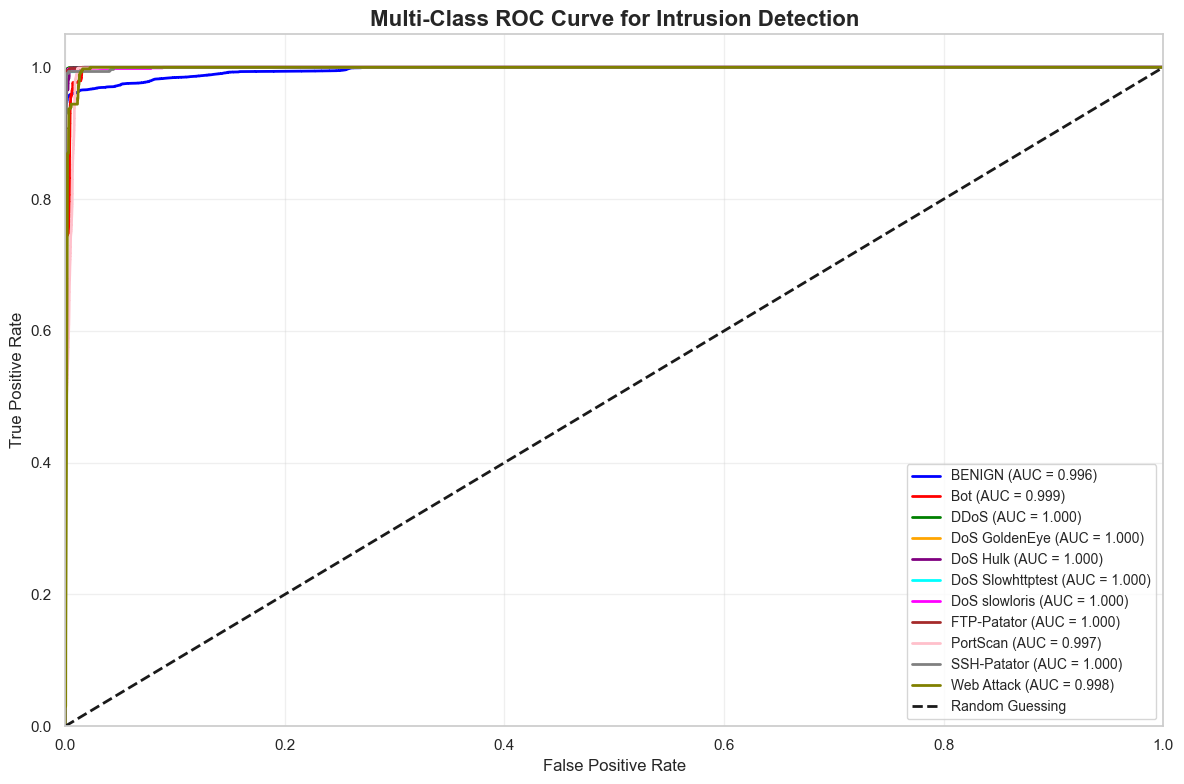

In [18]:
def plot_multiclass_roc(y_test, y_pred_prob, label_names):
    n_classes = len(label_names)
    fpr = dict()
    tpr = dict()
    roc_auc = dict()

    for i in range(n_classes):
        fpr[i], tpr[i], _ = roc_curve(y_test[:, i], y_pred_prob[:, i])
        roc_auc[i] = auc(fpr[i], tpr[i])

    plt.figure(figsize=(12, 8))
    colors = cycle(['blue', 'red', 'green', 'orange', 'purple', 'cyan', 'magenta', 'brown', 'pink', 'gray', 'olive'])
    
    for i, color in zip(range(n_classes), colors):
        plt.plot(fpr[i], tpr[i], color=color, lw=2,
                 label=f'{label_names[i]} (AUC = {roc_auc[i]:.3f})')

    plt.plot([0, 1], [0, 1], 'k--', lw=2, label='Random Guessing')
    plt.xlim([0.0, 1.0])
    plt.ylim([0.0, 1.05])
    plt.xlabel('False Positive Rate', fontsize=12)
    plt.ylabel('True Positive Rate', fontsize=12)
    plt.title('Multi-Class ROC Curve for Intrusion Detection', fontsize=16, fontweight='bold')
    plt.legend(loc="lower right", fontsize=10)
    plt.grid(alpha=0.3)
    plt.tight_layout()
    plt.show()

plot_multiclass_roc(y_test, y_pred_prob, label_names)

# Visual Justification of Model Outputs

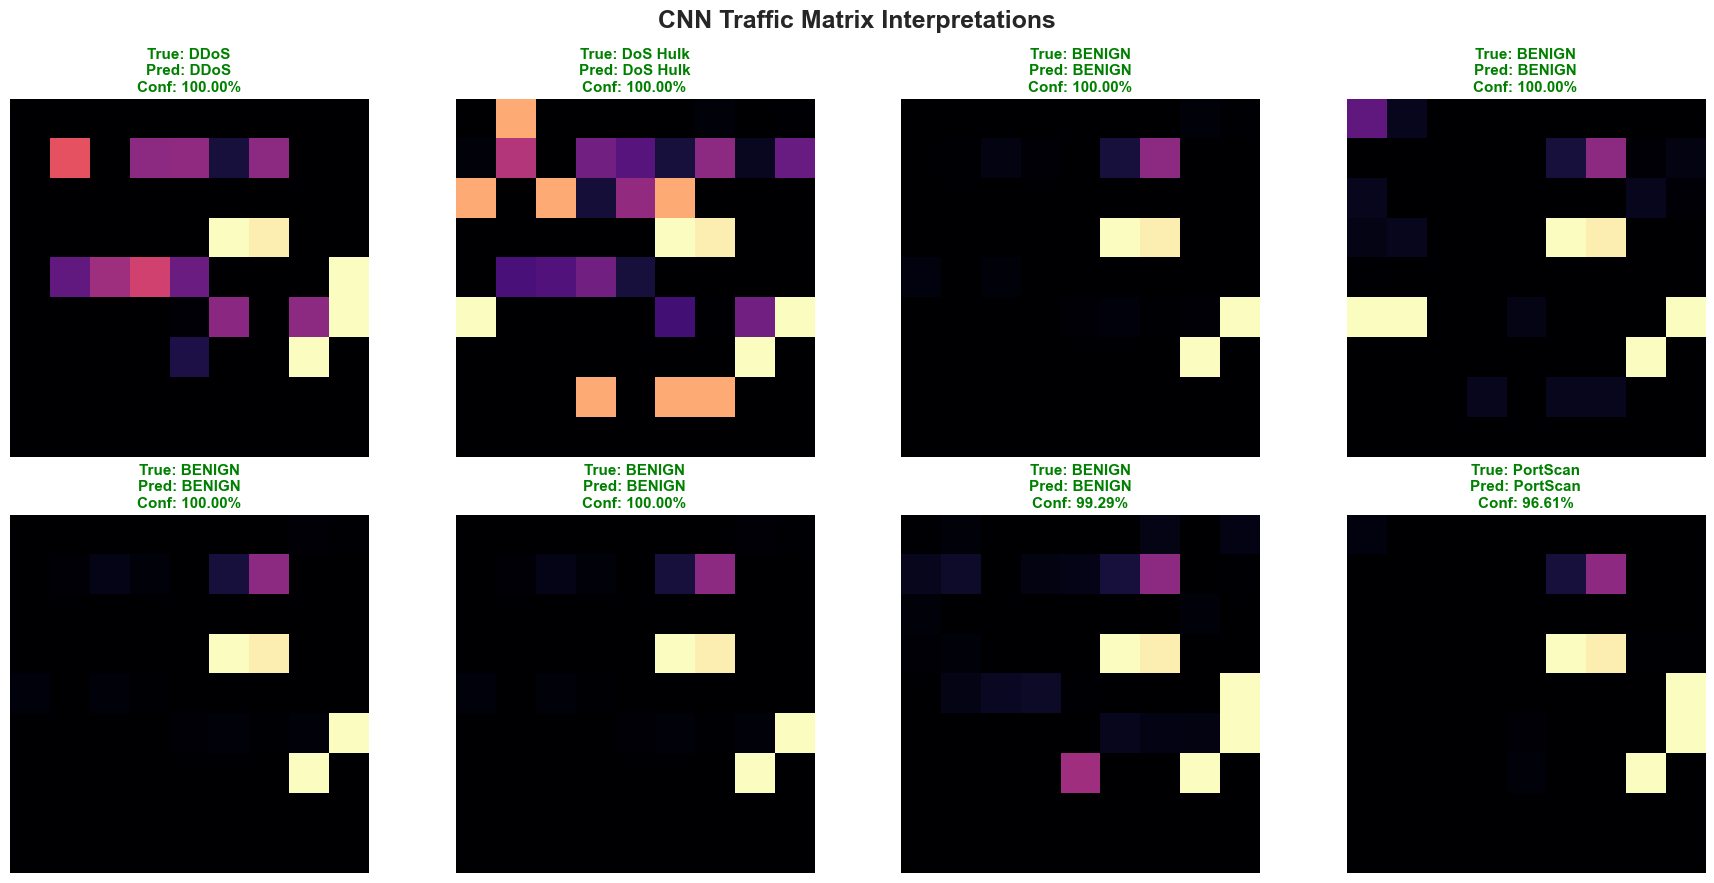

In [19]:
def visualize_predictions(X_test_img, y_true_idx, y_pred_idx, y_prob, labels, num_samples=8):
    import random
    
    indices = random.sample(range(len(X_test_img)), num_samples)
    
    fig, axes = plt.subplots(2, 4, figsize=(18, 9))
    axes = axes.flatten()
    
    for i, idx in enumerate(indices):
        img = X_test_img[idx].reshape(9, 9)
        true_label = labels[y_true_idx[idx]]
        pred_label = labels[y_pred_idx[idx]]
        confidence = y_prob[idx][y_pred_idx[idx]] * 100
        
        ax = axes[i]
        ax.imshow(img, cmap='magma', vmin=0, vmax=1)
        
        title_color = 'green' if true_label == pred_label else 'red'
        
        ax.set_title(f"True: {true_label}\nPred: {pred_label}\nConf: {confidence:.2f}%", 
                     fontsize=11, color=title_color, fontweight='bold')
        ax.axis('off')
        
    plt.suptitle('CNN Traffic Matrix Interpretations', fontsize=18, fontweight='bold')
    plt.tight_layout()
    plt.subplots_adjust(top=0.88)
    plt.show()

visualize_predictions(X_test, y_true_classes, y_pred_classes, y_pred_prob, label_names)